# SHAP Analysis — Vectyfi Radar XGBoost

Explain predictions of the XGBoost model trained to predict EU public tender award (`awarded` = 1 vs 0).

**Sections:**
1. Setup & data rebuild
2. SHAP explainer
3. Global importance (beeswarm + bar)
4. Dependence plots (top features)
5. Single-prediction waterfall

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

shap.initjs()
print("✅ All imports loaded")

/Users/basile/.pyenv/versions/3.14.3/envs/Vectyfi/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports loaded


## 2. Rebuild Data & Model

Replicates the exact preprocessing from the main notebook so SHAP runs against the same model.

In [48]:
FILE_PATH = '/Users/basile/code/Tescoa00/raw_data/export_CAN_2023_2018_balanced_500k.tsv'

columns_to_load = [
    # Identifiers & Target
    'ID_NOTICE_CAN',
    'ID_AWARD',           # Unique identifier for the contract award level
    'INFO_ON_NON_AWARD',  # Empty if awarded; populated if unsuccessful/discontinued

    # Safe Pre-Award Features
    'TOP_TYPE',           # Type of procedure (e.g., Open, Restricted)
    'TYPE_OF_CONTRACT',   # Works, Supplies, or Services
    'B_ACCELERATED',      # Accelerated procedure flag
    'CRIT_CODE',          # Lowest price vs. MEAT
    'CRIT_PRICE_WEIGHT',  # Weight given to price
    'CPV',                # Main procurement vocabulary code
    'ISO_COUNTRY_CODE',   # Country
    'B_EU_FUNDS',         # EU funding flag
    'B_FRA_AGREEMENT',    # Framework agreement flag
    'B_DYN_PURCH_SYST',   # Dynamic purchasing system flag
    'DT_DISPATCH',          # Dispatch date (can be used to derive days_to_deadline)
    'CAE_TYPE',             # Type of economic operator (e.g., SME, Large)
    'MAIN_ACTIVITY',        # Main activity of the economic operator
    'VALUE_EURO',           # Estimated value

]

df_raw = pd.read_csv(FILE_PATH, sep='\t', usecols=columns_to_load, nrows=500_000, low_memory=False)
df = df_raw.dropna(subset=['ID_AWARD']).drop_duplicates(subset=['ID_AWARD'])
print(f"✅ Loaded: {df_raw.shape[0]:,} rows * {df_raw.shape[1]} columns")

✅ Loaded: 500,000 rows * 17 columns


### Craft X and y

In [49]:
# Remove non-competitive procedures (NOC, NOP, AWP) to focus on competitive awards
direct_award_types = ['NOC', 'NOP', 'AWP']
competitive_mask = ~df['TOP_TYPE'].isin(direct_award_types)
original_len = len(df)
df = df[competitive_mask].copy()

# Target: "awarded" = 1, "PROCUREMENT_DISCONTINUED" / "PROCUREMENT_UNSUCCESSFUL" = 0
df['target'] = (df['INFO_ON_NON_AWARD'] == 'awarded').astype(int)

target_counts = df['target'].value_counts()
awarded_count     = target_counts.get(1, 0)
not_awarded_count = target_counts.get(0, 0)
print("\nCompetitive Target Distribution:")
print(f"Awarded (1):     {awarded_count:,}")
print(f"Not Awarded (0): {not_awarded_count:,}")
print(f"Percentage Not Awarded: {(not_awarded_count / len(df) * 100):.2f}%\n")

# scale_pos_weight quasi-balanced (~1.23), on le calcule quand même dynamiquement
scale_weight = not_awarded_count / awarded_count
print(f"scale_pos_weight: {scale_weight:.4f}")

X = df.drop(columns=['INFO_ON_NON_AWARD', 'target', 'ID_NOTICE_CAN', 'ID_AWARD'])
y = df['target']


Competitive Target Distribution:
Awarded (1):     198,994
Not Awarded (0): 245,414
Percentage Not Awarded: 55.22%

scale_pos_weight: 1.2333


### Features engineering

In [50]:
# Step 1: Handle Structural Missingness in the TRUE Pre-Award Estimated Value
cap_99 = df['VALUE_EURO'].quantile(0.99)
X['VALUE_EURO_LOG'] = np.log1p(
    X['VALUE_EURO']
    .clip(upper=cap_99)           # neutralise les 10 trillions
    .fillna(X['VALUE_EURO'].median())  # impute les 29% NaN
)
X = X.drop(columns=['VALUE_EURO'])

# Step 2: Clean CRIT_PRICE_WEIGHT & Add Missing Indicator
X['CRIT_PRICE_WEIGHT_MISSING'] = X['CRIT_PRICE_WEIGHT'].isna().astype(int)
X['CRIT_PRICE_WEIGHT'] = X['CRIT_PRICE_WEIGHT'].astype(str).str.replace('%', '').str.strip()
X['CRIT_PRICE_WEIGHT'] = pd.to_numeric(X['CRIT_PRICE_WEIGHT'], errors='coerce').fillna(0)

# Step 3: Binary Flag Mapping
binary_cols = ['B_FRA_AGREEMENT', 'B_DYN_PURCH_SYST', 'B_EU_FUNDS', 'B_ACCELERATED']
for col in binary_cols:
    X[col] = X[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

# Step 4: Temporal Features from DT_DISPATCH (avant de dropper)
dt = pd.to_datetime(X['DT_DISPATCH'], errors='coerce')
X['dispatch_month']   = dt.dt.month
X['dispatch_year']    = dt.dt.year
X['dispatch_quarter'] = dt.dt.quarter
X = X.drop(columns=['DT_DISPATCH'])

# Step 5: Categorical Grouping
X['CPV_DIVISION'] = X['CPV'].astype(str).str[:2]
X = X.drop(columns=['CPV'])

cat_cols = ['ISO_COUNTRY_CODE', 'TYPE_OF_CONTRACT', 'TOP_TYPE', 'CRIT_CODE',
            'CPV_DIVISION', 'CAE_TYPE', 'MAIN_ACTIVITY']  # ajout des colonnes string manquantes

for col in cat_cols:
    X[col] = X[col].fillna('UNKNOWN')

def group_low_freq(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    keep = freq[freq >= threshold].index
    return df[col].where(df[col].isin(keep), 'OTHER')

for col in cat_cols:
    X[col] = group_low_freq(X, col)

# Step 6: One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Step 7: Convertir les colonnes bool en int (compatibilité XGBoost)
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print("\nFinal Sanitization Complete!")
print(f"Final feature matrix shape: {X_encoded.shape}")


Final Sanitization Complete!
Final feature matrix shape: (444408, 74)


### Modeling

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.10, stratify=y, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print("✅ Model trained")

[0]	validation_0-aucpr:0.80459
[50]	validation_0-aucpr:0.85331
[100]	validation_0-aucpr:0.86251
[150]	validation_0-aucpr:0.86693
[199]	validation_0-aucpr:0.87085
✅ Model trained


In [52]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(xgb_model, X_test, y_test, n_repeats=10, random_state=42)

pi_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": pi.importances_mean,
    "std":        pi.importances_std
}).sort_values("importance", ascending=False)

# Afficher le tableau
print(pi_df.to_string(index=False))

# Features qui font du bruit (importance négative ou nulle)
print("\n⚠️ Features inutiles ou nuisibles:")
print(pi_df[pi_df["importance"] <= 0])

                                       feature  importance      std
                                VALUE_EURO_LOG    0.253151 0.002110
                           ISO_COUNTRY_CODE_RO    0.057996 0.000729
                                 dispatch_year    0.020018 0.000681
                               CPV_DIVISION_33    0.013447 0.000811
                           ISO_COUNTRY_CODE_SI    0.009905 0.000315
                             CRIT_CODE_UNKNOWN    0.006426 0.000491
                           ISO_COUNTRY_CODE_PL    0.006413 0.000505
                             CRIT_PRICE_WEIGHT    0.005430 0.000327
                               CPV_DIVISION_50    0.004001 0.000299
                          MAIN_ACTIVITY_Health    0.003373 0.000385
                                   CRIT_CODE_M    0.003355 0.000276
                           ISO_COUNTRY_CODE_HU    0.003024 0.000257
                                dispatch_month    0.002826 0.000241
                               CPV_DIVISION_77  

In [53]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")

ROC-AUC: 0.9005 | PR-AUC: 0.8709


In [61]:
shap_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': pi.importances_mean
})

# Extraire le préfixe (feature originale)
shap_df['original'] = shap_df['feature'].str.extract(r'^([A-Z_]+(?:_[A-Z]+)*)')

# Sommer par feature originale
shap_df.groupby('original')['importance'].sum().sort_values(ascending=False)

original
VALUE_EURO_LOG               0.253151
ISO_COUNTRY_CODE_RO          0.057996
CPV_DIVISION_                0.027727
ISO_COUNTRY_CODE_SI          0.009905
CRIT_CODE_UNKNOWN            0.006426
ISO_COUNTRY_CODE_PL          0.006413
CRIT_PRICE_WEIGHT            0.005430
CAE_TYPE_                    0.003508
MAIN_ACTIVITY_H              0.003468
CRIT_CODE_M                  0.003355
ISO_COUNTRY_CODE_HU          0.003024
ISO_COUNTRY_CODE_FR          0.002320
ISO_COUNTRY_CODE_ES          0.002273
B_FRA_AGREEMENT              0.002212
MAIN_ACTIVITY_E              0.002048
ISO_COUNTRY_CODE_SE          0.001996
ISO_COUNTRY_CODE_BG          0.001368
MAIN_ACTIVITY_P              0.001271
ISO_COUNTRY_CODE_DE          0.000988
CAE_TYPE_N                   0.000866
ISO_COUNTRY_CODE_LV          0.000855
TOP_TYPE_OPE                 0.000749
TYPE_OF_CONTRACT_U           0.000729
MAIN_ACTIVITY_OTHER          0.000594
ISO_COUNTRY_CODE_OTHER       0.000554
ISO_COUNTRY_CODE_CZ          0.000540
MAI

## 3. SHAP Explainer

We use `TreeExplainer` (exact, fast for XGBoost). We sample 5 000 test rows to keep plots readable.

In [54]:
SAMPLE_SIZE = 5000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=SAMPLE_SIZE, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)   # returns Explanation object

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value (log-odds): {shap_values.base_values[0]:.4f}")

SHAP values shape: (5000, 74)
Base value (log-odds): -0.2222


## 4. Global Feature Importance

### 4a. Beeswarm plot — shows impact distribution per feature

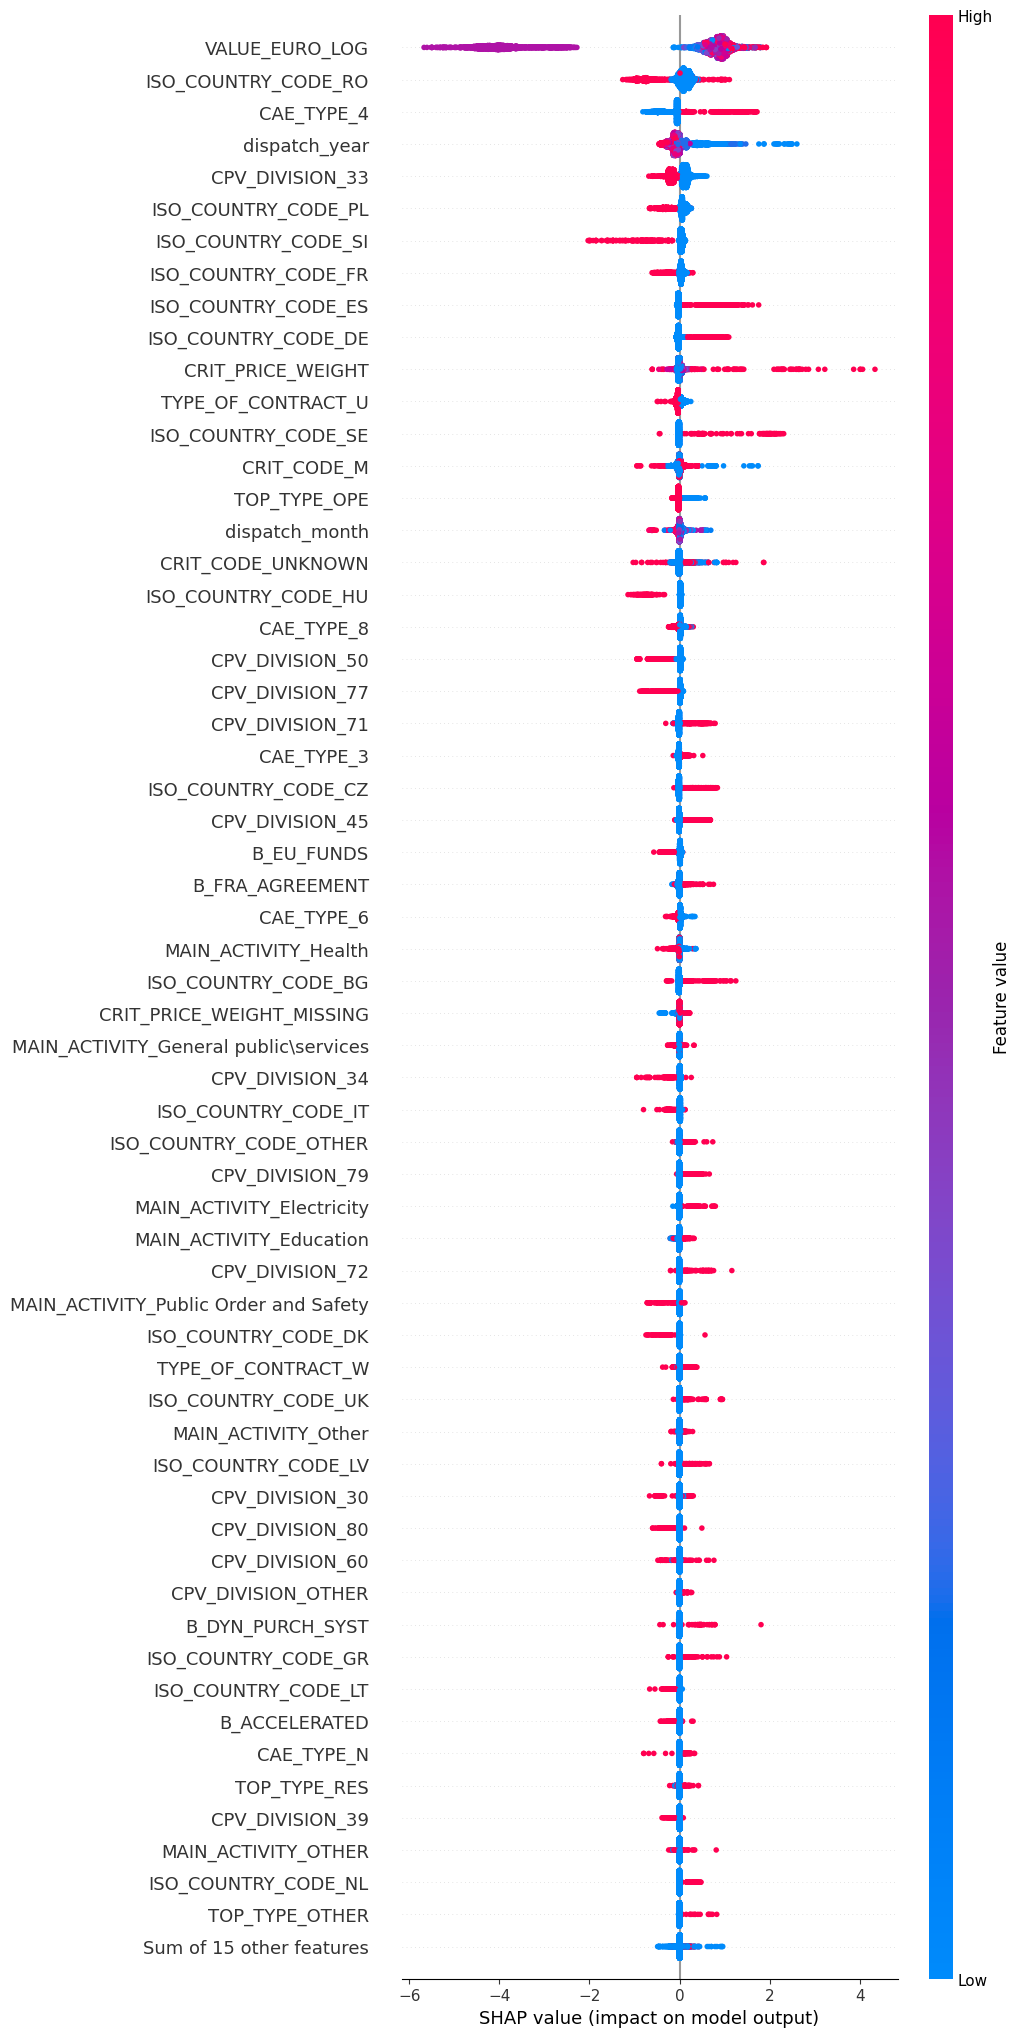

In [55]:
shap.plots.beeswarm(shap_values, max_display=60, show=True)

### 4b. Bar plot — mean |SHAP| per feature (simpler ranking)

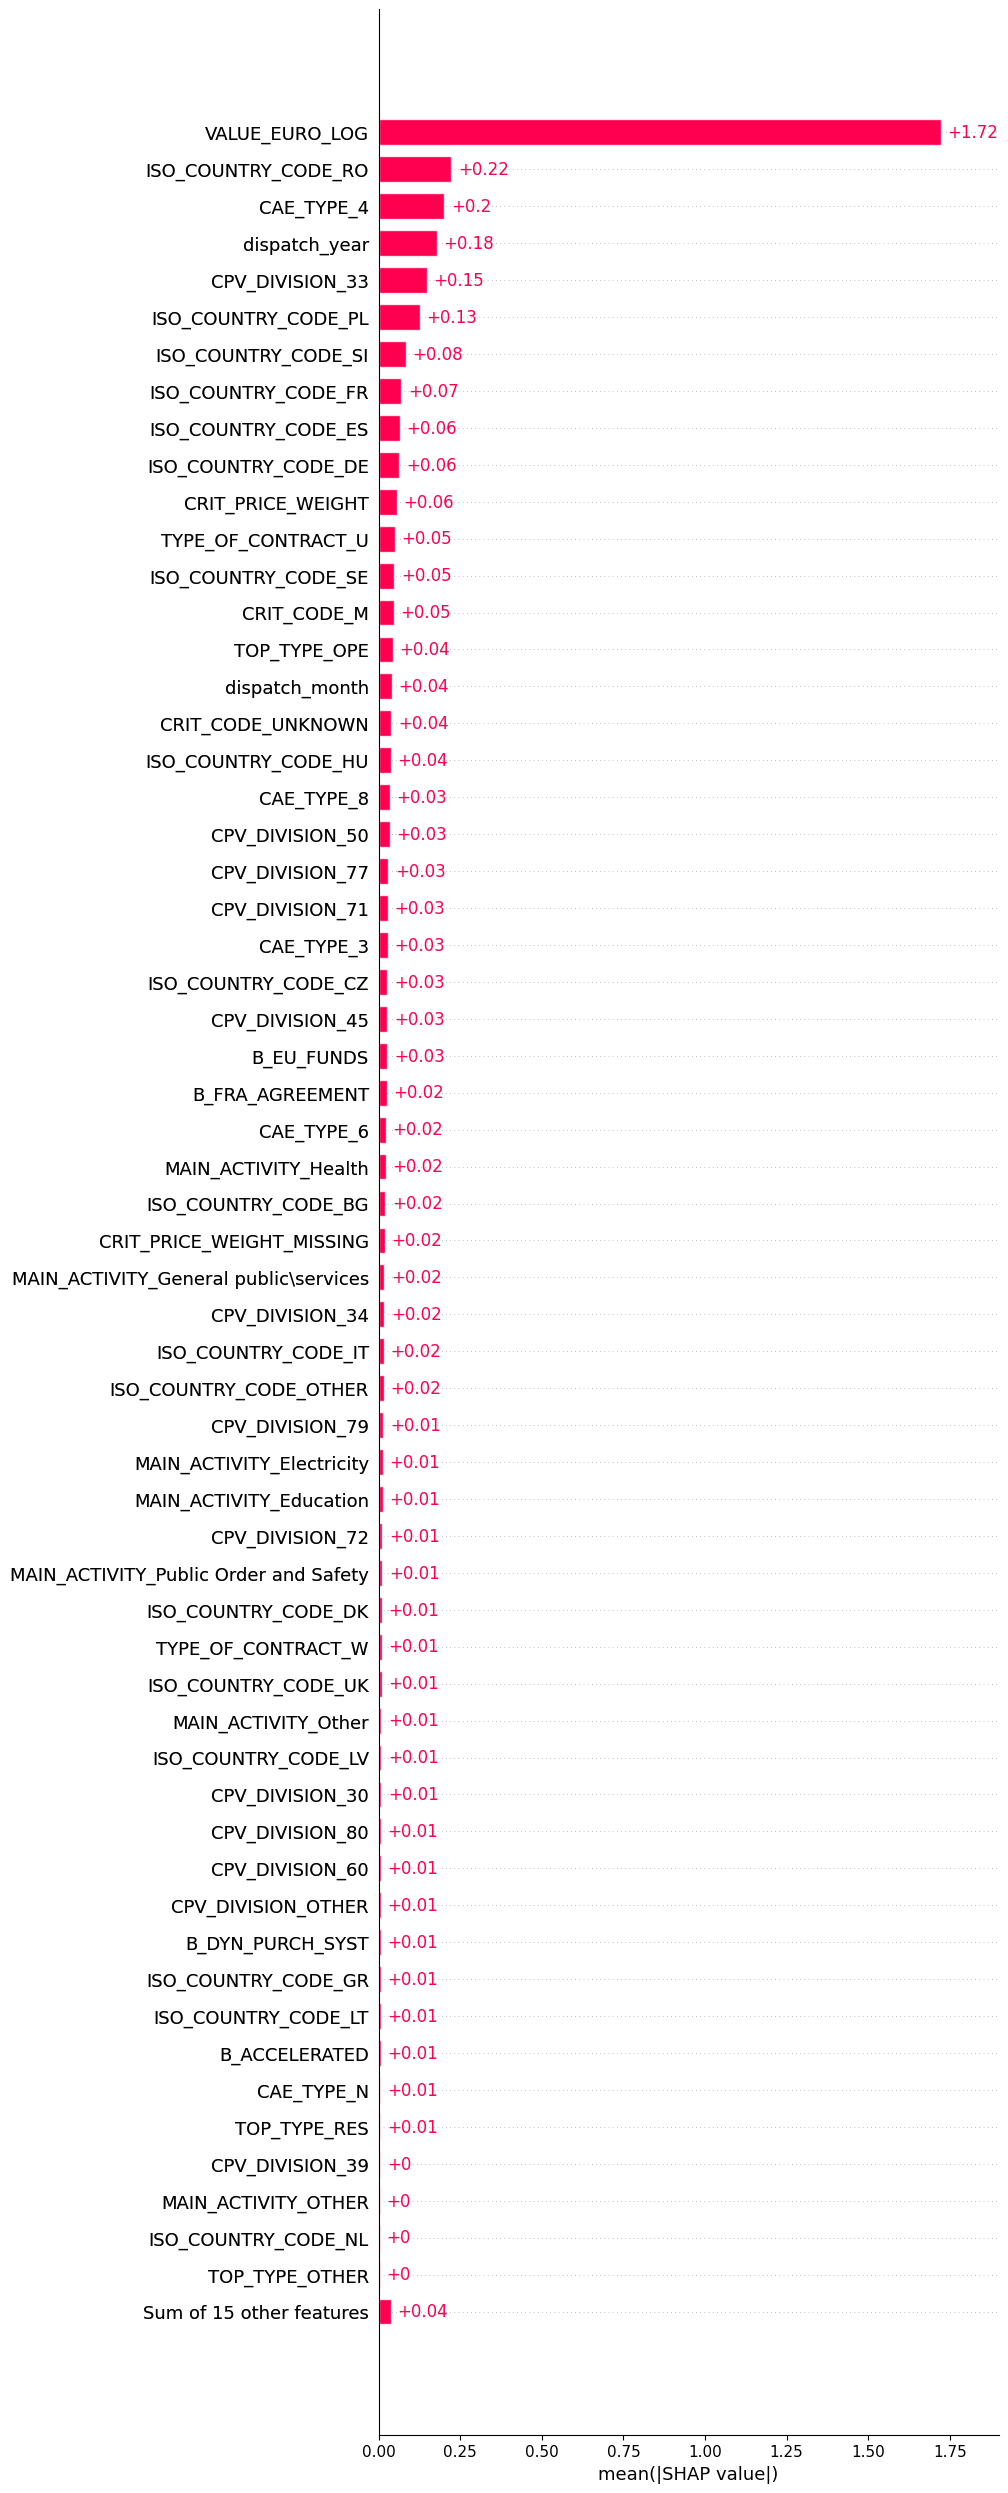

In [58]:
shap.plots.bar(shap_values, max_display=60, show=True)

In [59]:
corr = X_encoded['VALUE_EURO_LOG'].corr(y)
print(f"Corrélation VALUE_EURO_LOG / target: {corr:.3f}")

Corrélation VALUE_EURO_LOG / target: -0.069


## 5. Dependence Plots

How each top feature's value relates to its SHAP impact. The color encodes the most interacting feature (chosen automatically).

Top 5 features: ['VALUE_EURO_MISSING', 'VALUE_EURO', 'ISO_COUNTRY_CODE_RO', 'CAE_TYPE_4', 'dispatch_year']


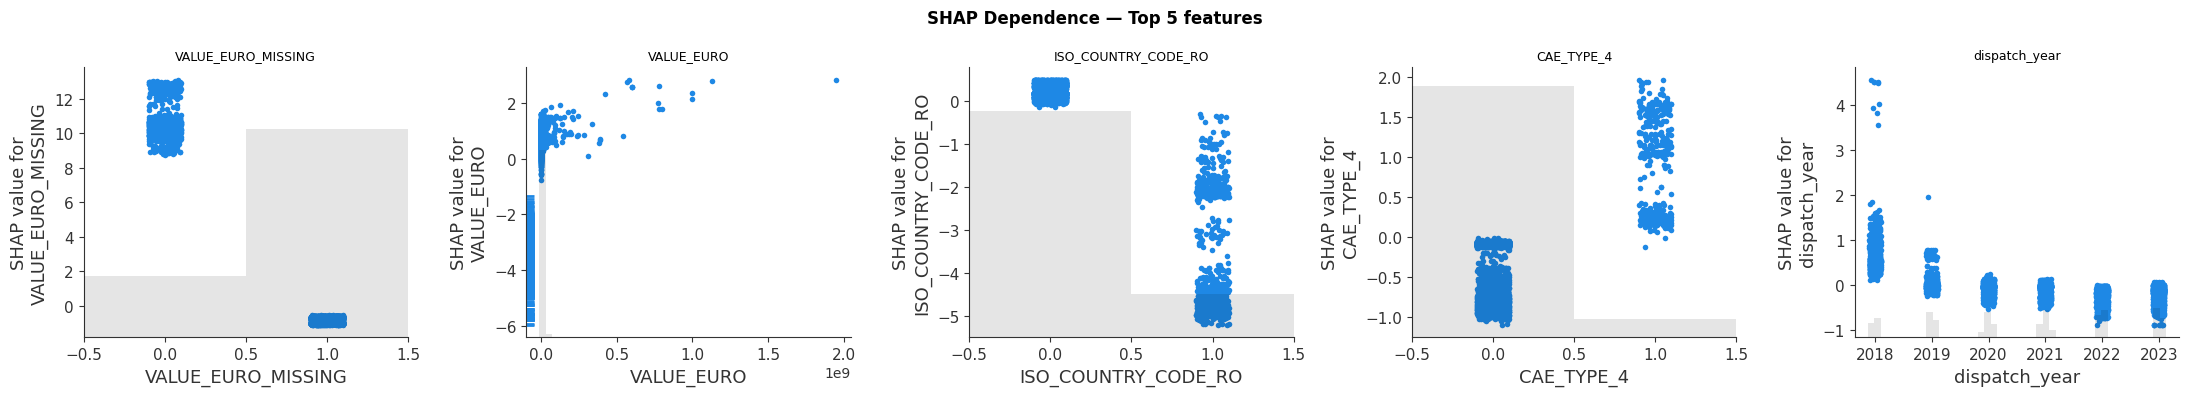

In [12]:
# Top-5 features by mean |SHAP|
mean_abs = np.abs(shap_values.values).mean(axis=0)
top5_features = X_sample.columns[np.argsort(mean_abs)[::-1][:5]].tolist()
print("Top 5 features:", top5_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feat in zip(axes, top5_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=9)
plt.suptitle("SHAP Dependence — Top 5 features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Waterfall — Single Prediction Explanation

Inspect one individual prediction (edit `ROW` to pick another).

Row 0 | True label: 1 | Predicted P(awarded): 0.923


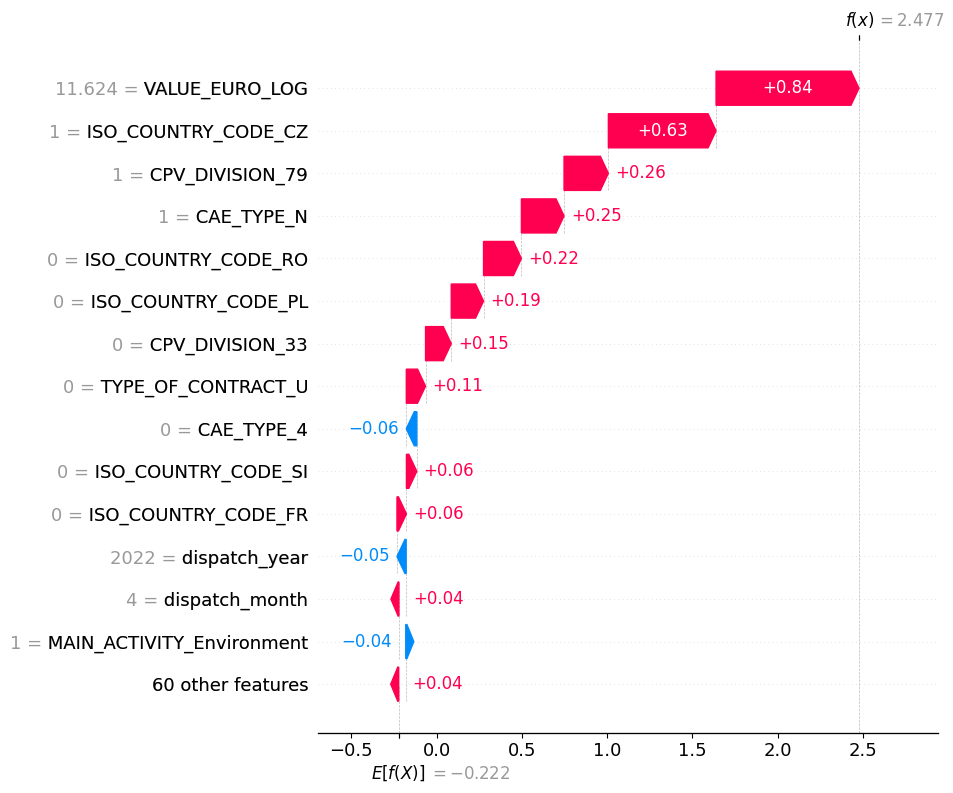

In [60]:
ROW = 0   # change to any index in [0, SAMPLE_SIZE)

pred_prob = xgb_model.predict_proba(X_sample.iloc[[ROW]])[0, 1]
true_label = y_test.iloc[sample_idx[ROW]]
print(f"Row {ROW} | True label: {true_label} | Predicted P(awarded): {pred_prob:.3f}")

shap.plots.waterfall(shap_values[ROW], max_display=15, show=True)

## 7. SHAP Values Table

Raw SHAP values for the sample — useful for downstream analysis or export.

In [ ]:
shap_df = pd.DataFrame(shap_values.values, columns=X_sample.columns)
shap_df.insert(0, 'awarded_true', y_test.iloc[sample_idx].values)
shap_df.insert(1, 'pred_prob', xgb.predict_proba(X_sample)[:, 1])

print(shap_df.shape)
shap_df.head()

(5000, 66)


,awarded_true,pred_prob,ID_NOTICE_CN,TED_NOTICE_URL,YEAR,ID_TYPE,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,...,B_LANGUAGE_ANY_EC,ADMIN_LANGUAGES_TENDER,ADMIN_OTHER_LANGUAGES_TENDER,B_RECURRENT_PROCUREMENT,cpv4,month_dispatch,is_end_of_year,days_to_deadline,has_value,has_corrections
0,1,0.999916,0.323402,0.219633,0.175159,0.023583,0.017208,0.001808,0.004012,0.012045,...,0.000006,0.002103,-0.000014,-0.009829,0.070721,-0.033142,-0.013204,-0.021830,-0.003319,0.003836
1,1,0.966151,0.081291,0.016300,0.011318,0.004967,0.013517,0.002775,-0.024186,0.000170,...,0.000004,0.195785,-0.000018,-0.020109,0.058629,0.011017,0.000529,0.135761,-0.007735,0.006505
2,1,0.955092,0.064683,0.012520,0.050953,0.007597,0.009451,0.003215,0.018042,-0.001584,...,0.000007,-0.256195,-0.000018,-0.006274,-0.060489,0.004176,0.000406,0.146034,-0.006036,0.000485
3,1,0.999977,-0.104347,0.086962,0.124078,0.022476,0.048608,0.001705,0.032654,0.000442,...,0.000006,3.173587,-0.000013,0.002988,0.082019,0.006214,-0.000170,0.311846,0.002036,0.000077
4,1,0.745645,0.001865,0.022642,-0.024169,0.002646,0.010237,0.002646,-0.005375,-0.000020,...,0.000012,-0.517244,-0.000016,-0.028823,0.244512,0.005489,0.008538,-0.139368,0.005377,-0.000528
